<a href="https://colab.research.google.com/github/AditiSinghal28/Machine-Learning-Projects/blob/ml/CIFAR_10_Object_Recognition_Using_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle

In [8]:
# configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
# dataset api
!kaggle competitions download -c cifar-10

 97% 695M/715M [00:11<00:00, 106MB/s] 
100% 715M/715M [00:11<00:00, 67.3MB/s]


In [10]:
!ls

cifar-10.zip  kaggle.json  sample_data


In [11]:
# extracting the compressed dataset
from zipfile import ZipFile
dataset = '/content/cifar-10.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [12]:
!ls

cifar-10.zip  sample_data	    test.7z   trainLabels.csv
kaggle.json   sampleSubmission.csv  train.7z


In [13]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.2 MB/s eta 0:00:00


In [14]:
import py7zr

archive = py7zr.SevenZipFile('/content/train.7z', mode='r')
archive.extractall()
archive.close()

In [15]:
# to extract to a particular folder
#archive.extractall(path = 'path_of_the_folder')

In [16]:
!ls

cifar-10.zip  sample_data	    test.7z  train.7z
kaggle.json   sampleSubmission.csv  train    trainLabels.csv


Importing the dependencies

In [17]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [18]:
filenames = os.listdir('/content/train')

In [19]:
type(filenames)

list

In [20]:
len(filenames)

50000

In [21]:
print(filenames[0:5])

['3359.png', '27700.png', '38430.png', '40926.png', '31838.png']


In [22]:
print(filenames[-5:])

['12230.png', '3238.png', '32507.png', '37145.png', '29317.png']


Labels Processing

In [23]:
labels_df = pd.read_csv('/content/trainLabels.csv')

In [24]:
labels_df.shape

(50000, 2)

In [25]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [26]:
labels_df[labels_df['id'] == 3359]

,id,label
3358,3359,horse


In [27]:
labels_df.head(10)

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile
5,6,automobile
6,7,bird
7,8,horse
8,9,ship
9,10,cat


In [28]:
labels_df['label'].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [29]:
labels_dictionary = {'airplane' : 0, 'automobile' : 1, 'bird' : 2, 'cat' : 3, 'deer' : 4, 'dog' : 5, 'frog' : 6, 'horse' : 7, 'ship' : 8, 'truck' : 9}

labels = [labels_dictionary[i] for i in labels_df['label']]


In [30]:
print(labels[0:5])

[6, 9, 9, 4, 1]


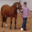

In [31]:
# displaying sample image
import cv2
from google.colab.patches import cv2_imshow
img = cv2.imread('/content/train/3359.png')
cv2_imshow(img)

In [32]:
id_list = list(labels_df['id'])

In [33]:
print(id_list[0:5])

[1, 2, 3, 4, 5]


In [34]:
print(id_list[-5:])

[49996, 49997, 49998, 49999, 50000]


Image processing

In [35]:
# convert images to numpy array

train_data_folder = '/content/train/'
data = []

for id in id_list:
  image = Image.open(train_data_folder + str(id) + '.png')
  image = np.array(image)
  data.append(image)

In [36]:
type(data)

list

In [37]:
len(data)

50000

In [38]:
type(data[0])

numpy.ndarray

In [39]:
data[0].shape

(32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
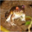

In [40]:
data[0]

In [41]:
# convert images and labels to numpy arrays
X = np.array(data)
Y = np.array(labels)

In [42]:
type(X)

numpy.ndarray

In [43]:
print(X.shape)

(50000, 32, 32, 3)


In [44]:
print(Y.shape)

(50000,)


Train Test Split

In [45]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 7)

In [46]:
print(X_train.shape)

(40000, 32, 32, 3)


In [47]:
print(X_test.shape)

(10000, 32, 32, 3)


In [48]:
# scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [49]:
X_train_scaled

array([[[[0.46666667, 0.44313725, 0.25098039],
         [0.50196078, 0.4745098 , 0.25490196],
         [0.48627451, 0.49803922, 0.24705882],
         ...,
         [0.44705882, 0.44313725, 0.22745098],
         [0.31764706, 0.33333333, 0.1372549 ],
         [0.41568627, 0.38823529, 0.16862745]],

        [[0.51372549, 0.49803922, 0.32156863],
         [0.54117647, 0.51764706, 0.34509804],
         [0.58039216, 0.52941176, 0.3254902 ],
         ...,
         [0.35294118, 0.36862745, 0.2       ],
         [0.25490196, 0.27843137, 0.10980392],
         [0.41176471, 0.39607843, 0.17647059]],

        [[0.49019608, 0.5254902 , 0.3254902 ],
         [0.49803922, 0.52941176, 0.34901961],
         [0.50588235, 0.51372549, 0.33333333],
         ...,
         [0.43137255, 0.45490196, 0.2627451 ],
         [0.31372549, 0.34117647, 0.18823529],
         [0.37254902, 0.37647059, 0.21176471]],

        ...,

        [[0.11372549, 0.18431373, 0.09803922],
         [0.06666667, 0.12941176, 0.0745098 ]

Building the NN

In [50]:
import tensorflow as tf
from tensorflow import keras

In [51]:
num_of_classes = 10

# setting up the layers of Neural Network
model = keras.Sequential([

    keras.layers.Flatten(input_shape = (32,32,3)),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(num_of_classes, activation = 'softmax')
])

# softmax is used usually when more than 2 labels
# sigmoid is used when 2 labels

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
# compliling the nn
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [53]:
# training the nn
model.fit(X_train_scaled, Y_train, validation_split = 0.1, epochs = 10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2509 - loss: 2.0572 - val_accuracy: 0.3235 - val_loss: 1.8650
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3337 - loss: 1.8530 - val_accuracy: 0.3560 - val_loss: 1.7955
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3595 - loss: 1.7972 - val_accuracy: 0.3458 - val_loss: 1.7963
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3806 - loss: 1.7598 - val_accuracy: 0.3555 - val_loss: 1.7830
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3796 - loss: 1.7340 - val_accuracy: 0.3663 - val_loss: 1.7696
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3877 - loss: 1.7208 - val_accuracy: 0.3853 - val_loss: 1.7160
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3952 - loss: 1.6970 - val_accuracy: 0.3575 - val_loss: 1.7771
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3926 - loss: 1.7065 - 

RESNET50

In [54]:
from tensorflow.keras import Sequential, models, layers
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers

In [55]:
convolutional_base = ResNet50(weights = 'imagenet', include_top = False, input_shape = (256,256,3))
convolutional_base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [56]:
model = models.Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(convolutional_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(num_of_classes, activation='softmax'))


In [57]:
model.compile(optimizer = optimizers.RMSprop(learning_rate=2e-5),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['acc'])


In [58]:
history = model.fit(X_train_scaled, Y_train, validation_split = 0.1, epochs = 10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 504s 401ms/step - acc: 0.3219 - loss: 2.0642 - val_acc: 0.7640 - val_loss: 0.8942
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 449s 400ms/step - acc: 0.6649 - loss: 1.0940 - val_acc: 0.8852 - val_loss: 0.4752
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 448s 398ms/step - acc: 0.7978 - loss: 0.7595 - val_acc: 0.9190 - val_loss: 0.3408
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 448s 398ms/step - acc: 0.8666 - loss: 0.5727 - val_acc: 0.9210 - val_loss: 0.2991
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 448s 398ms/step - acc: 0.9068 - loss: 0.4441 - val_acc: 0.9355 - val_loss: 0.2519
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 449s 399ms/step - acc: 0.9341 - loss: 0.3493 - val_acc: 0.9370 - val_loss: 0.2407
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 449s 399ms/step - acc: 0.9519 - loss: 0.2810 - val_acc: 0.9380 - val_loss: 0.2293
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 449s 399ms/step - acc: 0.9635 - loss: 0.2345 - val_acc: 0.9358 - val_loss: 0.2337
Epoch 9/

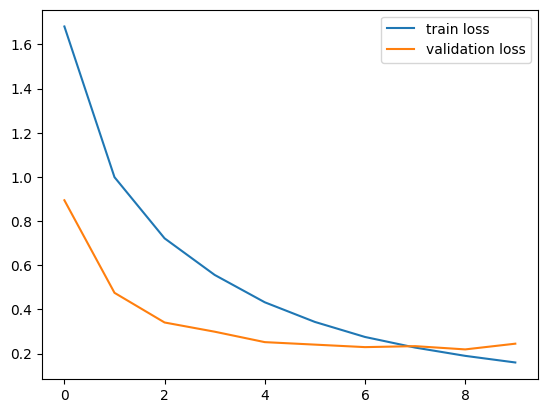

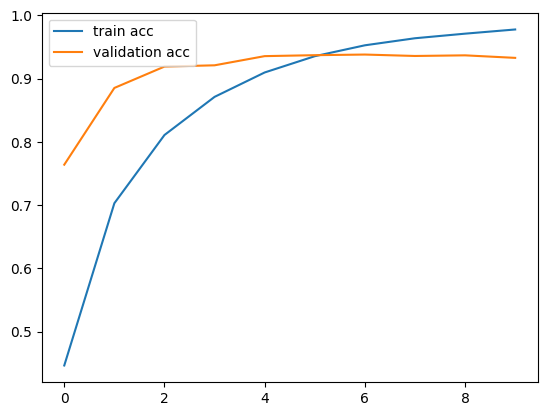

In [59]:
h = history

#plot the loss value
plt.plot(h.history['loss'], label = 'train loss')
plt.plot(h.history['val_loss'], label = 'validation loss')
plt.legend()
plt.show()

#plot the accuracy value
plt.plot(h.history['acc'], label = 'train acc')
plt.plot(h.history['val_acc'], label = 'validation acc')
plt.legend()
plt.show()

In [60]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy : ', accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - acc: 0.9350 - loss: 0.2416
Test Accuracy :  0.9352999925613403
